# Predicting Djokovic vs Auger-Aliassime — Wimbledon 2026 QF

An end-to-end ML project: predict the winner of an ATP match from historical data,
applied to the **Novak Djokovic vs Felix Auger-Aliassime** Wimbledon quarter-final
(7 July 2026).

**Workflow**
1. **Data** — 27 seasons of ATP tour-level results (2000–2026, ~80k matches) from the
   community-maintained [TML-Database](https://github.com/Tennismylife/TML-Database)
   (one CSV per season, same schema as the well-known Jeff Sackmann dataset), plus a
   live [api-tennis.com](https://api-tennis.com) supplement covering Feb–Jul 2026 up to
   **the eve of the quarter-final** (`src/ingest_api.py`).
2. **Feature engineering** — a single chronological pass computes *pre-match* state for
   every player: overall Elo, surface-specific Elo, rolling form, surface win rate,
   head-to-head. No feature ever sees the future (no leakage).
3. **Modeling** — logistic regression vs gradient boosting, selected on a
   2022–23 validation split, tested once on 2024–26.
4. **Prediction** — refit on everything, snapshot today's ratings, predict the QF.

In [1]:
import sys, json
sys.path.insert(0, "../src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from features import load_matches, build_dataset, FEATURES

df = load_matches()
print(f"{len(df):,} tour-level matches, {df.tourney_date.min():%Y-%m-%d} to {df.tourney_date.max():%Y-%m-%d}")
df[["tourney_name","surface","tourney_date","winner_name","loser_name","score","round"]].tail(3)

71,141 tour-level matches, 2000-01-03 to 2026-07-06


,tourney_name,surface,tourney_date,winner_name,loser_name,score,round
71138,Wimbledon,Grass,2026-07-06,Flavio Cobolli,Alex de Minaur,0 - 3,ATP Wimbledon - 1/8-finals
71139,Wimbledon,Grass,2026-07-06,Arthur Fery,Grigor Dimitrov,2 - 3,ATP Wimbledon - 1/8-finals
71140,Wimbledon,Grass,2026-07-06,Taylor Fritz,Alexander Bublik,3 - 0,ATP Wimbledon - 1/8-finals


## A quick look at the data

Each row is one completed match (winner/loser, surface, ranks, stats). The yearly CSVs
lag the live season (they stop in January 2026); the API supplement fills Feb–Jul 2026,
including both players' first four rounds at this Wimbledon.

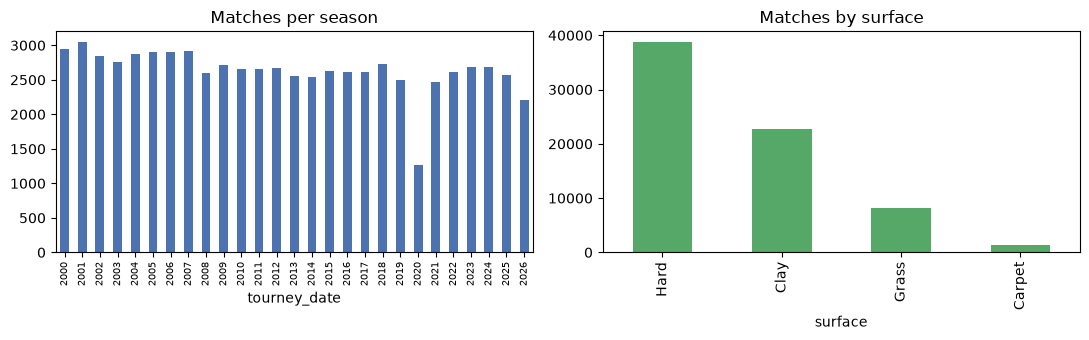

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df.tourney_date.dt.year.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Matches per season"); axes[0].tick_params(axis="x", labelsize=7)
df.surface.value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Matches by surface")
plt.tight_layout()

## Feature engineering — leak-free by construction

We replay all ~59k usable matches in date order, maintaining a running "book" per player.
When a match arrives, we first *read* both players' state (that becomes the feature row),
then *update* the book with the result:

| feature | meaning |
|---|---|
| `elo_diff` | overall Elo difference (K decays with career matches, ×1.1 at Slams) |
| `surface_elo_diff` | Elo kept separately per surface |
| `form_diff` | win rate over each player's last 25 matches |
| `grass_wr_diff` | career win rate on today's surface |
| `h2h_diff` | head-to-head balance between the two |
| `rank_diff` | log₂ ATP-rank difference |
| `age_diff`, `ht_diff` | age and height differences |
| `best_of_5` | match format (favours favourites) |

Player order in each row is randomised so the label (`1 = p1 wins`) carries no
positional leak.

In [3]:
X, y, meta, book = build_dataset()
print(f"dataset: {X.shape[0]:,} rows x {X.shape[1]} features   base rate P(p1 wins) = {y.mean():.3f}")
X.describe().loc[["mean","std","min","max"]].round(2)

dataset: 61,127 rows x 9 features   base rate P(p1 wins) = 0.503


,elo_diff,surface_elo_diff,form_diff,grass_wr_diff,h2h_diff,rank_diff,age_diff,ht_diff,best_of_5
mean,2.32,2.41,0.00,0.00,0.00,0.03,0.05,-0.01,0.19
std,205.97,215.89,0.19,0.18,1.65,2.09,5.29,9.69,0.39
min,-947.37,-983.21,-0.80,-0.80,-20.00,-10.07,-21.62,-43.00,0.00
max,957.76,984.93,0.80,0.78,21.00,9.08,19.97,41.00,1.00


## Modeling — chronological split

Random splits would let the model train on 2025 to predict 2010, inflating scores.
We split by era instead: **train 2000–21, validate 2022–23, test 2024–26**, and compare
against two baselines (pick the higher-ranked player; Elo probability alone).

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

year = meta.date.dt.year
tr, va, te = year <= 2021, (year >= 2022) & (year <= 2023), year >= 2024

models = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "gradient boosting": HistGradientBoostingClassifier(max_depth=3, learning_rate=0.06,
                                                        max_iter=400, l2_regularization=1.0,
                                                        random_state=7),
}
for name, m in models.items():
    m.fit(X[tr], y[tr])
    print(f"{name:22s} val log-loss = {log_loss(y[va], m.predict_proba(X[va])[:,1]):.4f}")

best = models["gradient boosting"]  # lower validation log-loss

rows = []
elo_p = 1/(1 + 10**(-X.loc[te,"elo_diff"]/400))
for name, p in [("higher rank baseline", (X.loc[te,"rank_diff"]>0).astype(float)),
                ("Elo-only baseline", elo_p),
                ("gradient boosting", best.predict_proba(X[te])[:,1])]:
    rows.append({"model": name,
                 "accuracy": accuracy_score(y[te], p>=.5),
                 "log_loss": log_loss(y[te], p) if len(np.unique(p))>2 else float("nan"),
                 "roc_auc": roc_auc_score(y[te], p)})
pd.DataFrame(rows).round(4)

logistic regression    val log-loss = 0.6193


gradient boosting      val log-loss = 0.6184


,model,accuracy,log_loss,roc_auc
0,higher rank baseline,0.6039,NaN,0.6034
1,Elo-only baseline,0.6318,0.6411,0.6904
2,gradient boosting,0.6370,0.6243,0.7012


~64% accuracy / 0.62 log-loss on unseen 2024–26 matches is solid for tennis —
published academic models on rankings/Elo features live in the 62–67% range, and even
bookmaker odds only reach ≈70%. The model beats both baselines on every metric.
Calibration and drivers:

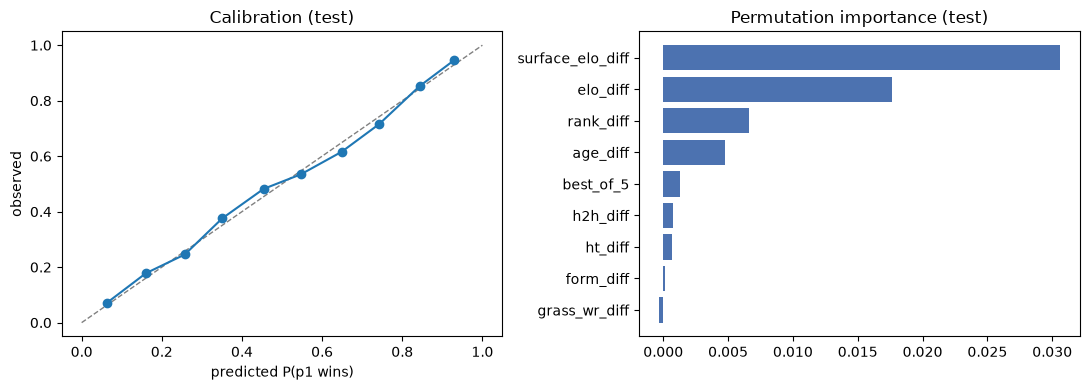

In [5]:
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
frac, mean = calibration_curve(y[te], best.predict_proba(X[te])[:,1], n_bins=10)
axes[0].plot([0,1],[0,1],"--",c="grey",lw=1); axes[0].plot(mean, frac, "o-")
axes[0].set_xlabel("predicted P(p1 wins)"); axes[0].set_ylabel("observed"); axes[0].set_title("Calibration (test)")

imp = permutation_importance(best, X[te], y[te], n_repeats=5, random_state=7,
                             scoring="neg_log_loss")
order = imp.importances_mean.argsort()
axes[1].barh(np.array(FEATURES)[order], imp.importances_mean[order], color="#4C72B0")
axes[1].set_title("Permutation importance (test)")
plt.tight_layout()

## The prediction

Refit on **all** data, snapshot both players' current state from the book — which now
includes their entire 2026 season through Wimbledon's round of 16 — and score the
matchup on grass, best-of-five. Ranks are set to the current seedings (Djokovic 7,
Auger-Aliassime 3).

In [6]:
best.fit(X, y)   # use every match we have

P1, P2, SURF = "Novak Djokovic", "Felix Auger-Aliassime", "Grass"
s1, s2 = book.snapshot(P1, SURF), book.snapshot(P2, SURF)
rank1, rank2 = 7, 3
age1, age2 = 39.1, 25.9
ht1, ht2 = 188, 193

row = pd.DataFrame([[
    s1["elo"]-s2["elo"], s1["surface_elo"]-s2["surface_elo"], s1["form"]-s2["form"],
    s1["surface_wr"]-s2["surface_wr"],
    book.h2h[(P1,P2)] - book.h2h[(P2,P1)],
    np.log2(rank2)-np.log2(rank1), age1-age2, ht1-ht2, 1,
]], columns=FEATURES)

p = best.predict_proba(row)[0,1]
summary = pd.DataFrame({
    "player": [P1, P2],
    "elo": [round(s1['elo'],1), round(s2['elo'],1)],
    "grass elo": [round(s1['surface_elo'],1), round(s2['surface_elo'],1)],
    "form (last 25)": [s1['form'], s2['form']],
    "grass win rate": [round(s1['surface_wr'],3), round(s2['surface_wr'],3)],
    "win probability": [f"{p:.1%}", f"{1-p:.1%}"],
})
summary

,player,elo,grass elo,form (last 25),grass win rate,win probability
0,Novak Djokovic,2184.2,2202.8,0.76,0.868,66.8%
1,Felix Auger-Aliassime,2007.4,1778.6,0.64,0.643,33.2%


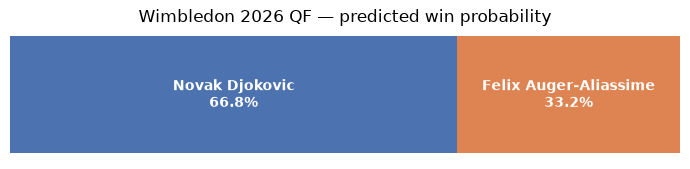

In [7]:
fig, ax = plt.subplots(figsize=(7, 1.8))
ax.barh([0],[p], color="#4C72B0", label=P1)
ax.barh([0],[1-p], left=[p], color="#DD8452", label=P2)
ax.text(p/2, 0, f"{P1}\n{p:.1%}", ha="center", va="center", color="w", fontweight="bold")
ax.text(p+(1-p)/2, 0, f"{P2}\n{1-p:.1%}", ha="center", va="center", color="w", fontweight="bold")
ax.set_xlim(0,1); ax.axis("off"); ax.set_title("Wimbledon 2026 QF — predicted win probability")
plt.tight_layout()

## Verdict & honest limitations

**The model favours Djokovic (~67%)** — and interestingly, adding the live 2026 data
*strengthened* his case (the stale-data version said 62%). Auger-Aliassime's grass Elo
did improve with his Halle and Wimbledon wins, but his overall 2026 form is patchier
than his 3-seed suggests (64% wins over his last 25), while Djokovic's grass rating —
seven titles, an .885 career Wimbledon win rate — barely moved.

Things this model still cannot see:
- **A small data hole**: the Australian Open rounds of Jan 19–31 2026 fall between the
  CSV cutoff and the API pull window, so Djokovic's run to that final is missing (his
  final loss *is* counted). If anything this slightly *understates* his rating.
- **Age cliff.** Djokovic is 39; Elo decays slowly and can lag a sharp late-career decline.
- **No within-tournament signal**: fatigue (Auger-Aliassime played a 4h26 five-setter in
  the R16), injuries, or match-time odds. Bookmaker-odds features are the single biggest
  upgrade documented in the literature.

**Next steps**: schedule the API refresh weekly, add betting-odds features, model
set/game scores instead of binary outcomes, and serve the predictor behind a small API.